# 03b-07 - The Orthomosaic, by Hand

The last box of the lecture's pipeline is the orthomosaic, and 03-06 opened it as a file without asking how it was made. It was made from everything the six notebooks before this one built. The block of 03b-04 says where every photograph was taken and how the camera was turned, and the surface model of 03b-06 says how high the ground and everything on it stands. With those two, a photograph can be undone. Every cell of the surface model is a point in space, the collinearity equations say which pixel of a photograph that point was imaged in, and the colour of that pixel, put into the cell, is the photograph with its perspective removed. The lecture called that differential rectification, ordinary rectification performed independently on myriad small patches, and the patches are the cells.

The software did this for every photograph of the flight, chose one photograph for every face of its mesh, levelled the seams and rendered the result from straight above. We do it by hand for the pinned window of P03, with the photograph that sees that window best, in a few lines and a fraction of a second. Then we do it with a second photograph and see where the two disagree, we put the software's mosaic beside ours, and we end with the experiment the lecture's relief frame asked for, the same photograph rectified onto the terrain model instead of the surface model, so that the roof leans again exactly as it does in the State's and the federal orthophotos.

This notebook reads the flight named in `data/flight.json`, and was written on the pre-flight of 17 September 2026. Before you run anything, choose *File*, then *Save As*, and give the copy a name with `-mywork` in it, so that next week's pull never collides with your work.

In [1]:
import json
import math
import time

import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.windows import from_bounds
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

flight = json.load(open("data/flight.json"))
choices = flight["p03b"]
reference = json.load(open("data/ground_truth.json"))["p03b"]
print(f"this notebook reads the flight {flight['label']} of {flight['date']}: {flight['aircraft']} at {flight['altitude_agl_m']} m, {flight['n_photos']} photographs, processed with {flight['processing']['software']}")

this notebook reads the flight flight-2026-09-23 of 2026-09-23: DJI Mini 3 at 79.3 m, 85 photographs, processed with OpenDroneMap


## The photograph that sees the window best

The pipeline that built this kit ranked every photograph of the flight by how much of the window's surface it sees and by how close its principal ray, the line straight out of the lens, meets the ground to the window's centre, and the winner is `photo_a.jpg`. Its choice travels in `flight.json`, and the software's block with its calibrated camera travels in `block.npz`. The first thing to do is to retype the four pieces of 03b-04 that turn a pose into a picture, the rotation matrix from the software's axis angle vector, the collinearity equations with the Brown distortion, and from them where the lens was and which way it looked. The poses we take are the map-frame ones, because the surface model lives in the map frame, and with them we can check the pipeline's choice from the pose alone:

In [2]:
block = np.load("data/block.npz")
camera = json.loads(str(block["camera"]))                       # the camera the flight calibrated, in normalised units
names = [str(n) for n in block["names"]]
offset = np.asarray(block["offset"], dtype=float)               # the map frame is the products' coordinate system minus this
photo = choices["photos"]["a"]
shot = names.index(photo["name"])
img_a = np.asarray(Image.open("data/photo_a.jpg").convert("RGB"))
sh, sw = img_a.shape[:2]                                        # the kit's sample, always taken from the image itself

def rodrigues(rv):
    # the rotation matrix of the software's axis angle vector
    rv = np.asarray(rv, dtype=float); theta = float(np.linalg.norm(rv))
    if theta < 1e-12:
        return np.eye(3)
    k = rv / theta
    K = np.array([[0.0, -k[2], k[1]], [k[2], 0.0, -k[0]], [-k[1], k[0], 0.0]])
    return np.eye(3) + math.sin(theta) * K + (1.0 - math.cos(theta)) * K @ K

def project_brown(X, rotation, translation, camera, width, height):
    # the collinearity equations, world points into pixels of an image of the given size, through the Brown distortion
    X = np.atleast_2d(np.asarray(X, dtype=float))
    p = X @ rodrigues(rotation).T + np.asarray(translation, dtype=float)     # into the camera's frame
    depth = p[:, 2]
    with np.errstate(divide="ignore", invalid="ignore"):
        x, y = p[:, 0] / depth, p[:, 1] / depth                               # the perspective division
    r2 = x * x + y * y
    radial = 1.0 + camera["k1"] * r2 + camera["k2"] * r2 ** 2 + camera["k3"] * r2 ** 3
    xd = x * radial + 2.0 * camera["p1"] * x * y + camera["p2"] * (r2 + 2.0 * x * x)
    yd = y * radial + 2.0 * camera["p2"] * x * y + camera["p1"] * (r2 + 2.0 * y * y)
    size = max(width, height)                                                 # normalised units are fractions of the longer side
    u = (camera["focal_x"] * xd + camera["c_x"]) * size + width / 2.0 - 0.5
    v = (camera["focal_y"] * yd + camera["c_y"]) * size + height / 2.0 - 0.5
    return u, v, depth

def camera_centre(rotation, translation):
    # where the lens was, minus R transposed times t
    return -rodrigues(rotation).T @ np.asarray(translation, dtype=float)

def camera_axis(rotation):
    # the direction the camera looked, the principal ray in the world's axes
    return rodrigues(rotation).T @ np.array([0.0, 0.0, 1.0])

rot_a, tr_a = block["rotation_map"][shot], block["translation_map"][shot]    # the map frame, where the surface model lives
centre_a, axis_a = camera_centre(rot_a, tr_a), camera_axis(rot_a)
with rasterio.open("data/dsm_window.tif") as src:
    dsm = src.read(1, masked=True).filled(np.nan); dsm_transform = src.transform; bounds = src.bounds; cell = float(src.res[0])
with rasterio.open("data/dtm_window.tif") as src:
    dtm = src.read(1, masked=True).filled(np.nan); dtm_transform = src.transform
z_ground = float(np.nanmedian(dtm))                                          # the window's terrain, one height for the whole of it
along = (z_ground - centre_a[2]) / axis_a[2]                                 # how far along the principal ray the ground lies
hit = centre_a + along * axis_a + np.r_[offset, 0.0]
window_centre = np.array(choices["window"]["centre"])
print(f"the photograph        {photo['name']}, shot {shot} of {len(names)}, in the kit as {photo['kit_file']} at {sw} by {sh} pixels")
print(f"sees                  {photo['coverage']:.1%} of the window's surface   reference {reference['ortho']['coverage_a']:.1%}")
print(f"principal ray         meets the ground {math.hypot(*(hit[:2] - window_centre)):.2f} m from the window's centre   flight.json {photo['principal_ray_distance_m']} m")
print(f"tilt from the nadir   {math.degrees(math.acos(max(-1.0, min(1.0, -axis_a[2])))):.2f} degrees   flight.json {photo['tilt_deg']} degrees")
print(f"the lens              {centre_a[2] - z_ground:.1f} m above the window's terrain, whose median height in the model is {z_ground:.2f} m")

the photograph        DJI_0823.JPG, shot 11 of 85, in the kit as photo_a.jpg at 2000 by 1500 pixels
sees                  100.0% of the window's surface   reference 100.0%
principal ray         meets the ground 25.90 m from the window's centre   flight.json 25.84 m
tilt from the nadir   1.23 degrees   flight.json 1.23 degrees
the lens              73.1 m above the window's terrain, whose median height in the model is -87.61 m


Read the five lines against each other. The coverage is the pipeline's reason for the choice, the share of the window's surface that falls inside this frame. The distance from the principal ray to the window's centre is the tie-breaker, and recomputing it from the pose alone lands on the number the pipeline wrote, which says our four functions agree with the software's. The tilt is how far the camera looked from straight down; the smaller it is, the closer the nadir, the point on the ground directly under the lens, sits to the centre of the frame. The last line is the flying height the relief formula needs, the lens above the window's terrain rather than above the take-off point, and it comes out of the pose, not out of the file's altitude. The terrain's height beside it is the model's own, as the receiver placed the block, which 03-07 and 03-08 sort out; only the difference matters here, and a negative number is not a hole.

Here is the photograph itself, with the window's outline projected into it through the same equations, the four corners of the surface model's extent at the terrain's height, and the nadir marked:

flying height over the window   73.1 m   reference 73.1
nadir to the window's centre    24.9 m   reference 24.9
the tallest things, p95 height  9.59 m above the terrain   reference 9.59
one pixel of the sample         5.74 cm on the window's ground   reference 5.74
lean = r h / H                  3.27 m, or 57 pixels of the sample   reference 3.27 m, 57 px


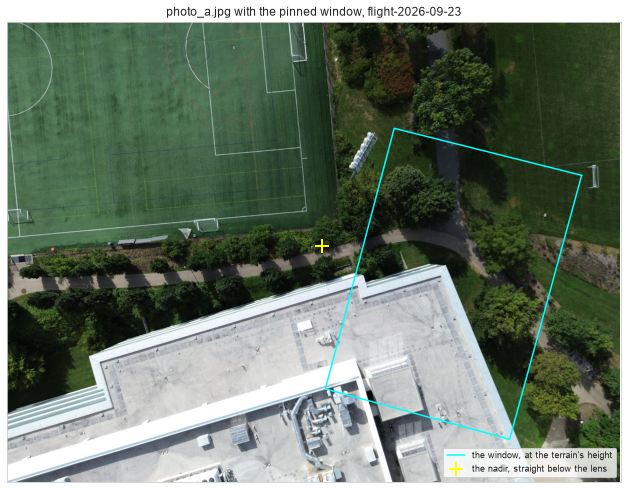

In [3]:
corners = np.array([[bounds.left, bounds.top], [bounds.right, bounds.top], [bounds.right, bounds.bottom], [bounds.left, bounds.bottom]]) - offset
cu, cv, _ = project_brown(np.column_stack([corners, np.full(4, z_ground)]), rot_a, tr_a, camera, sw, sh)
nu, nv, _ = project_brown([[centre_a[0], centre_a[1], z_ground]], rot_a, tr_a, camera, sw, sh)   # the nadir, straight below the lens
height = dsm - dtm                                                                             # how far the surface stands above the terrain
h95 = float(np.nanpercentile(height, 95))
H_fly = float(centre_a[2] - z_ground)
r_m = float(math.hypot(*(centre_a[:2] + offset - window_centre)))
gsd_sample = H_fly / (camera["focal_x"] * max(sw, sh))               # metres per pixel of the sample, on the window's ground
lean_m = r_m * h95 / H_fly

fig, ax = plt.subplots(figsize=(12, 6.9))
ax.imshow(img_a)
ax.plot(np.r_[cu, cu[0]], np.r_[cv, cv[0]], color="cyan", linewidth=1.5, label="the window, at the terrain's height")
ax.scatter(nu, nv, marker="+", s=220, color="yellow", linewidth=2, label="the nadir, straight below the lens")
ax.set_xlim(0, sw); ax.set_ylim(sh, 0); ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc="lower right", fontsize=9)
ax.set_title(f"{photo['kit_file']} with the pinned window, {flight['label']}", fontsize=12)
fig.tight_layout()
print(f"flying height over the window   {H_fly:.1f} m   reference {reference['ortho']['flying_height_over_window_m']}")
print(f"nadir to the window's centre    {r_m:.1f} m   reference {reference['ortho']['nadir_to_window_centre_m']}")
print(f"the tallest things, p95 height  {h95:.2f} m above the terrain   reference {reference['dem']['height_p95_m']}")
print(f"one pixel of the sample         {gsd_sample * 100:.2f} cm on the window's ground   reference {reference['ortho']['gsd_at_sample_cm']}")
print(f"lean = r h / H                  {lean_m:.2f} m, or {lean_m / gsd_sample:.0f} pixels of the sample   reference {reference['ortho']['lean_of_p95_height_m']} m, {reference['ortho']['lean_of_p95_height_px_at_sample']:.0f} px")

The window is the cyan outline, turned in the frame because the camera's heading was whatever the aircraft's was, not north, and the cross is the nadir. Everything tall in the window leans away from that cross, the roof and the crowns alike, and the farther from the cross the more; look at the roof and notice that the only wall you can see is the one facing the cross, which is what a roof pushed away from the nadir looks like from above. The numbers under the picture are the lecture's relief formula filled in for this window. The flying height is the lens over the terrain, the radial distance is from the nadir to the window's centre, and the height is that of the tallest things the window holds, taken as the ninety-fifth percentile of the surface above the terrain so that one stray point does not set it; the lean their ratio predicts is printed in metres and in pixels of the sample. Keep that number in mind. It is what the surface model has to undo, and in the last section it is what comes back.

## Rectification, the collinearity equations run backwards

An orthophoto is made cell by cell. Take a cell of the surface model. Its column and row give its easting and northing through the raster's transform, and its value gives its height, so the cell is a point in space. Send that point through the collinearity equations with the photograph's pose and it lands on a pixel; the colour of that pixel is what the camera saw at that place, and it goes into the cell. Do that for every cell and the photograph has been laid onto the surface, which is all that rectification is. The equations run in the same direction as in 03b-04, world into image, and what is reversed is the question. There we asked where a point would fall in the photograph and compared it with where the feature was found. Here we ask, for a place on the map, what colour the photograph had there. Cells whose pixel falls outside the frame, or that lie behind the camera, stay empty, and nothing here interpolates, so a cell takes the one pixel nearest to where its point landed:

1000 by 700 cells of 5 cm rectified in 0.05 s; the photograph covers 100.00% of them   reference 100.00%


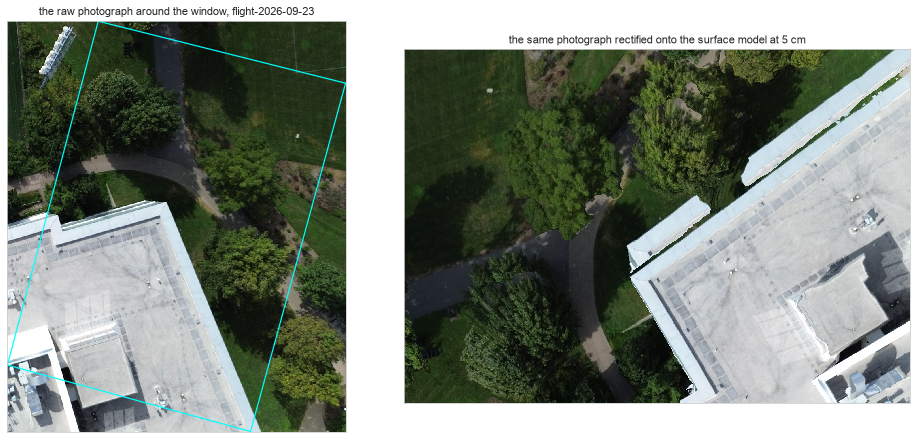

In [4]:
def orthorectify(surface, transform, image, rotation, translation, camera, offset):
    # one photograph laid onto a surface model, cell by cell; returns the picture and the mask of cells the photograph covers
    rows, cols = surface.shape
    r, c = np.meshgrid(np.arange(rows), np.arange(cols), indexing="ij")
    X = transform.c + (c + 0.5) * transform.a - offset[0]             # the cell centre's easting, in the map frame the poses use
    Y = transform.f + (r + 0.5) * transform.e - offset[1]             # and its northing (transform.e is negative, rows run south)
    Z = np.asarray(surface, dtype=float)
    valid = np.isfinite(Z)                                            # cells the surface model has no height for stay empty
    H, W = image.shape[:2]
    u, v, depth = project_brown(np.column_stack([X.ravel(), Y.ravel(), Z.ravel()]), rotation, translation, camera, W, H)
    ui, vi = np.round(u).astype(int), np.round(v).astype(int)         # the nearest pixel, no interpolation
    inside = valid.ravel() & (depth > 0) & (ui >= 0) & (ui < W) & (vi >= 0) & (vi < H)
    out = np.zeros((rows * cols,) + image.shape[2:], dtype=image.dtype)
    out[inside] = image[vi[inside], ui[inside]]
    return out.reshape((rows, cols) + image.shape[2:]), inside.reshape(rows, cols)

t0 = time.time()
ortho_a, covered_a = orthorectify(dsm, dsm_transform, img_a, rot_a, tr_a, camera, offset)
seconds = time.time() - t0
extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)
print(f"{dsm.shape[1]} by {dsm.shape[0]} cells of {cell * 100:.0f} cm rectified in {seconds:.2f} s; the photograph covers {covered_a.mean():.2%} of them   reference {reference['ortho']['covered_share']:.2%}")

u0, u1 = int(max(0, np.floor(cu.min()))), int(min(sw, np.ceil(cu.max())))      # the raw photograph, cropped to the window's outline
v0, v1 = int(max(0, np.floor(cv.min()))), int(min(sh, np.ceil(cv.max())))
fig, axes = plt.subplots(1, 2, figsize=(14, 6.2))
axes[0].imshow(img_a[v0:v1, u0:u1], extent=(u0, u1, v1, v0), interpolation="nearest")
axes[0].plot(np.r_[cu, cu[0]], np.r_[cv, cv[0]], color="cyan", linewidth=1.2)
axes[0].set_xlim(u0, u1); axes[0].set_ylim(v1, v0)
axes[0].set_title(f"the raw photograph around the window, {flight['label']}", fontsize=11)
axes[1].imshow(ortho_a, extent=extent, interpolation="nearest")
axes[1].set_title(f"the same photograph rectified onto the surface model at {cell * 100:.0f} cm", fontsize=11)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

The line says how many cells there were, how long they took and how many of them the photograph reached; the cells it did not reach are the black corner, if there is one, where the window ran past the frame's edge. Now the two pictures. On the left is the photograph as the camera took it, with the window's outline turned in it, and the roof shows its walls, because a camera to one side of a building sees its side. On the right every cell holds the colour of the place it stands for, the paths cross where the map says they cross, and the roof sits over its own footprint with no wall in sight, because the surface model gave every roof cell the roof's height and the equations found the roof's pixel for it. Look along the roof's edge nearest the nadir for a pale band. Those are the cells where the surface model ramps from the ground to the roof over a few cells, and each of them was sent to a pixel on the wall, which the photograph shows foreshortened; a surface model is never exactly vertical at a wall, and this is what that costs. Look also at the crowns. They are round and plausible, and they are also wherever the surface model put them, which 03b-06 showed is the highest point per cell, so a crown's edge in an orthophoto is the edge of a model, not of a tree.

## A second photograph, and the seam

One photograph never covers a whole site, so a mosaic is a set of rectified photographs and a rule for which one to use where. The simplest rule is the one the lecture's relief formula suggests. A cell should come from the photograph whose nadir is nearest to it, because there the relief displacement, and with it every error of the surface model, is smallest. Here is `photo_b.jpg`, the pair's second photograph, rectified onto the same grid, and the two combined by that rule, with the cells the first photograph missed filled from the second. Where both photographs cover a cell we can also ask whether they agree on its colour, and the map of their disagreement is the seam map, the picture a mosaicking program looks at when it decides where to cut:

the nadir of photo_a.jpg lies 24.9 m from the window's centre, that of photo_b.jpg 29.4 m
the second photograph covers 89.0% of the cells and takes 27.7% of the mosaic   reference 27.7%
both cover 89.0% of the window; there the grey values differ by a median of 5.7 DN, and by more than 40 DN on 4.2% of those cells


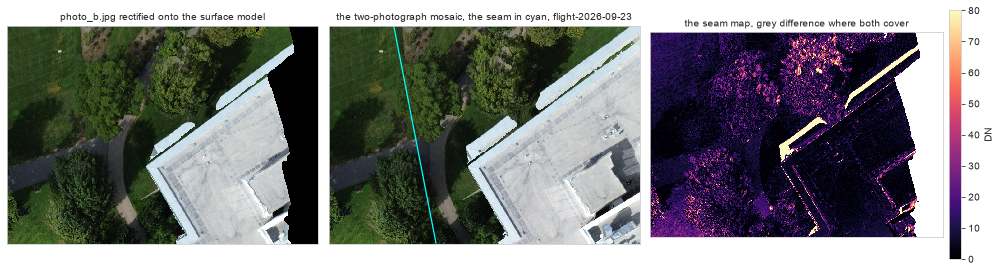

In [5]:
img_b = np.asarray(Image.open("data/photo_b.jpg").convert("RGB"))
shot_b = names.index(choices["photos"]["b"]["name"])
rot_b, tr_b = block["rotation_map"][shot_b], block["translation_map"][shot_b]
ortho_b, covered_b = orthorectify(dsm, dsm_transform, img_b, rot_b, tr_b, camera, offset)
nadir_a = centre_a[:2] + offset                                           # the nadir points, in the products' coordinates
nadir_b = camera_centre(rot_b, tr_b)[:2] + offset
rows, cols = dsm.shape
r, c = np.meshgrid(np.arange(rows), np.arange(cols), indexing="ij")
X = dsm_transform.c + (c + 0.5) * dsm_transform.a                         # every cell centre's easting
Y = dsm_transform.f + (r + 0.5) * dsm_transform.e                         # and northing
use_b = (np.hypot(X - nadir_b[0], Y - nadir_b[1]) < np.hypot(X - nadir_a[0], Y - nadir_a[1])) & covered_b   # the nearer nadir wins
use_b |= (~covered_a) & covered_b                                         # and b fills what a never saw
mosaic_hand = np.where(use_b[..., None], ortho_b, ortho_a)
both = covered_a & covered_b
seam = np.where(both, np.abs(ortho_a.astype(float).mean(axis=2) - ortho_b.astype(float).mean(axis=2)), np.nan)
print(f"the nadir of {photo['kit_file']} lies {math.hypot(*(nadir_a - window_centre)):.1f} m from the window's centre, that of {choices['photos']['b']['kit_file']} {math.hypot(*(nadir_b - window_centre)):.1f} m")
print(f"the second photograph covers {covered_b.mean():.1%} of the cells and takes {use_b.mean():.1%} of the mosaic   reference {reference['ortho']['two_photograph_mosaic_share_from_b']:.1%}")
print(f"both cover {both.mean():.1%} of the window; there the grey values differ by a median of {np.nanmedian(seam):.1f} DN, and by more than 40 DN on {(seam[both] > 40).mean():.1%} of those cells")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
axes[0].imshow(ortho_b, extent=extent, interpolation="nearest")
axes[0].set_title(f"{choices['photos']['b']['kit_file']} rectified onto the surface model", fontsize=10)
axes[1].imshow(mosaic_hand, extent=extent, interpolation="nearest")
if use_b.any() and not use_b.all():
    axes[1].contour(X, Y, use_b.astype(float), levels=[0.5], colors="cyan", linewidths=1.2)
axes[1].set_title(f"the two-photograph mosaic, the seam in cyan, {flight['label']}", fontsize=10)
im = axes[2].imshow(seam, extent=extent, cmap="magma", vmin=0, vmax=80, interpolation="nearest")
axes[2].set_title("the seam map, grey difference where both cover", fontsize=10)
fig.colorbar(im, ax=axes[2], fraction=0.04, pad=0.02, label="DN")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

The first line is the geometry of the choice, the two nadirs' distances from the window's centre, and the second is what the rule made of it. The nearer nadir takes the larger share, and a photograph whose nadir lies farther out gets only the corner nearest to it plus whatever the first photograph missed. The seam in the middle panel is that boundary. Nothing breaks along it on the lawn or the paths, because both photographs were rectified onto the same surface and the surface is right there. The seam map on the right says where the two photographs disagree, in DN, the digital numbers of the eight-bit grey scale, and the third line above gives its median and how much of the shared area lies beyond forty of them. The bright places are of three kinds. The crowns, because the two cameras looked into them from different sides and the surface model has one height for what is really a cloud of leaves; the wall of the building on the side facing the nadirs, because the surface model is not vertical there and each photograph smeared a different piece of wall across those cells; and anything that moved between the two exposures, a person on the path, a car, a branch in the wind. The disagreement sits where the surface model is wrong or where something moved, and nowhere else. A good seam avoids all of it, and a mosaicking program finds such a seam by searching this map for the cheapest path, which the nearest-nadir rule does not do.

## The software's mosaic beside yours

The kit carries the software's own orthomosaic over the same window, at the software's own resolution, which need not be the surface model's. To compare the two cell by cell we read the software's file straight onto the surface model's grid, asking `rasterio` for the window under the surface model's bounds and for an output of the surface model's shape, with averaging so that several of its pixels become one of ours. Then the grey value of every cell we covered is set against the software's, as a correlation, as a median absolute difference and as the share of cells that differ by more than forty DN, which is a disagreement you can see:

the software's mosaic is 1667 by 1167 pixels of 3 cm, read onto our 1000 by 700 cells of 5 cm   reference 1667 by 1167
correlation of the grey values on the covered cells   0.882   reference 0.882
median absolute difference                            11.7 DN   reference 11.7
cells that differ by more than 40 DN                  11.58%   reference 11.58%


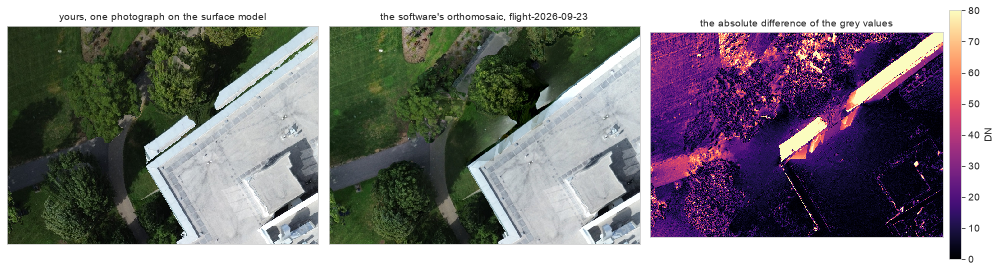

In [6]:
with rasterio.open("data/ortho_window.tif") as src:
    win = from_bounds(bounds.left, bounds.bottom, bounds.right, bounds.top, transform=src.transform)
    mosaic_soft = src.read(window=win, out_shape=(3, rows, cols), resampling=Resampling.average)
    print(f"the software's mosaic is {src.width} by {src.height} pixels of {src.res[0] * 100:.0f} cm, read onto our {cols} by {rows} cells of {cell * 100:.0f} cm   reference {reference['ortho']['mosaic_size'][0]} by {reference['ortho']['mosaic_size'][1]}")
grey_hand = ortho_a.astype(float).mean(axis=2)
grey_soft = mosaic_soft.astype(float).mean(axis=0)
diff = np.abs(grey_hand - grey_soft)
print(f"correlation of the grey values on the covered cells   {np.corrcoef(grey_hand[covered_a], grey_soft[covered_a])[0, 1]:.3f}   reference {reference['ortho']['correlation_with_mosaic']}")
print(f"median absolute difference                            {np.median(diff[covered_a]):.1f} DN   reference {reference['ortho']['median_abs_difference_dn']}")
print(f"cells that differ by more than 40 DN                  {(diff[covered_a] > 40).mean():.2%}   reference {reference['ortho']['share_beyond_40_dn']:.2%}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
axes[0].imshow(ortho_a, extent=extent, interpolation="nearest")
axes[0].set_title("yours, one photograph on the surface model", fontsize=10)
axes[1].imshow(np.moveaxis(mosaic_soft, 0, -1), extent=extent, interpolation="nearest")
axes[1].set_title(f"the software's orthomosaic, {flight['label']}", fontsize=10)
im = axes[2].imshow(np.where(covered_a, diff, np.nan), extent=extent, cmap="magma", vmin=0, vmax=80, interpolation="nearest")
axes[2].set_title("the absolute difference of the grey values", fontsize=10)
fig.colorbar(im, ax=axes[2], fraction=0.04, pad=0.02, label="DN")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

Read the correlation first. It is the agreement of two pictures made from the same flight by two very different routes, one photograph laid onto a grid by a dozen lines of code against the whole pipeline, and a high value says that the orthomosaic is, in the end, this operation. The median difference is a few grey levels, which is the difference between a nearest pixel and an average of several, plus the colour balancing the software applied, and the share beyond forty DN is where the two pictures genuinely disagree. The map on the right says where. It is the same map as the seam map, the crowns and the wall facing the nadir, and for the same reason; look along the building's edge for the largest values, where the software's roof edge is clean and ours carries the smeared wall. The software did not pick one photograph per cell. It textured its mesh, choosing for every face the photograph that saw the face most squarely, and then levelled the colour across the seams so that no boundary shows; the orthomosaic is that textured mesh rendered from straight above, every ray vertical, which is why its roof edge is crisp where our single-photograph product smears a wall. That is two sentences on a method that fills a paper, and the resources at the end have the paper.

## The same photograph on the terrain model, and on the bare ground

Now the experiment the lecture's relief frame asked for. The State's orthophoto and the federal one were made exactly as we just did, with one difference. Their surface was a terrain model, the bare ground, because a terrain model exists for the whole state and a surface model of every roof and crown does not. We do it twice. First onto `dtm_window.tif`, the software's terrain model of 03b-06, and then onto a flat plane at the lawn's level, the lower quartile of that terrain model, which is what a terrain model that knows nothing of buildings holds where the building stands. Between the two we find the roof itself, as the largest flat region standing more than eight metres over the lawn's level, and ask the software's terrain model what it made of it, because 03b-06 found that the ground filter's largest window is narrower than this building:

the roof, the largest flat region more than 8 m over the lawn's level, covers 448 m2 and stands 10.95 m over it   reference 448.0 m2, 10.95 m
in the software's terrain model the roof stands 0.00 m above the terrain, so the terrain model kept it   reference 0.0 m
on the terrain model the photograph covers 100.00% of the cells, on the ground plane 100.00%; on the surface model it covered 100.00%
the relief formula for the roof: r = 25.5 m from the nadir, h = 11.0 m, H = 73.1 m, a lean of 3.82 m or 76 cells   reference 3.82 m
the first section predicted 3.27 m for the tallest things, the crowns   reference 3.27 m


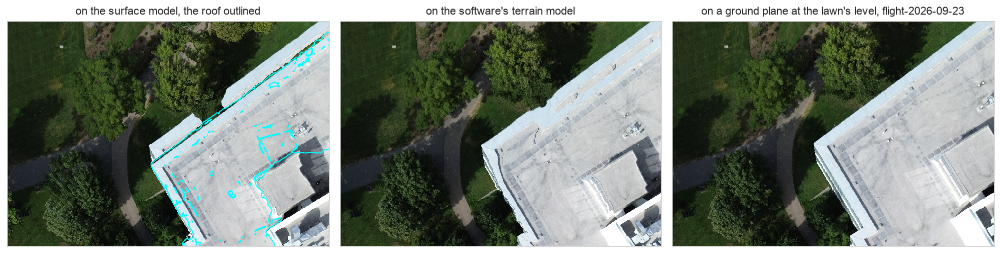

In [7]:
from scipy import ndimage as ndi

ortho_terrain, covered_terrain = orthorectify(dtm, dtm_transform, img_a, rot_a, tr_a, camera, offset)
ground_level = float(np.nanpercentile(dtm, 25))                                     # the lawn's level, the lower quartile of the terrain model
plane = np.full_like(dsm, ground_level)
ortho_plane, covered_plane = orthorectify(plane, dsm_transform, img_a, rot_a, tr_a, camera, offset)

gy, gx = np.gradient(np.nan_to_num(dsm))                                             # the roof: flat, and high over the lawn
roof = ndi.binary_opening((dsm > ground_level + 8) & (np.hypot(gx, gy) < 0.05), iterations=3)
labels, n_regions = ndi.label(roof)
sizes = ndi.sum(roof, labels, range(1, n_regions + 1))
roof = labels == (int(np.argmax(sizes)) + 1)                                         # the largest such region
rr, cc = np.nonzero(roof)
roof_height = float(np.nanmedian(dsm[roof]) - ground_level)
kept = float(np.nanmedian((dsm - dtm)[roof]))
r_roof = math.hypot(X[rr, cc].mean() - nadir_a[0], Y[rr, cc].mean() - nadir_a[1])
lean_roof = r_roof * roof_height / H_fly
roof_ref = reference["ortho"]["roof"]
print(f"the roof, the largest flat region more than 8 m over the lawn's level, covers {roof.sum() * cell * cell:.0f} m2 and stands {roof_height:.2f} m over it   reference {roof_ref['area_m2']} m2, {roof_ref['height_m']} m")
print(f"in the software's terrain model the roof stands {kept:.2f} m above the terrain, so the terrain model {'kept it' if kept < 1 else 'removed it'}   reference {roof_ref['height_above_dtm_m']} m")
print(f"on the terrain model the photograph covers {covered_terrain.mean():.2%} of the cells, on the ground plane {covered_plane.mean():.2%}; on the surface model it covered {covered_a.mean():.2%}")
print(f"the relief formula for the roof: r = {r_roof:.1f} m from the nadir, h = {roof_height:.1f} m, H = {H_fly:.1f} m, a lean of {lean_roof:.2f} m or {lean_roof / cell:.0f} cells   reference {roof_ref['lean_on_ground_plane_m']} m")
print(f"the first section predicted {lean_m:.2f} m for the tallest things, the crowns   reference {reference['ortho']['lean_of_p95_height_m']} m")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
axes[0].imshow(ortho_a, extent=extent, interpolation="nearest")
axes[0].contour(X, Y, roof.astype(float), levels=[0.5], colors="cyan", linewidths=1.0)
axes[0].set_title("on the surface model, the roof outlined", fontsize=11)
axes[1].imshow(ortho_terrain, extent=extent, interpolation="nearest")
axes[1].set_title("on the software's terrain model", fontsize=11)
axes[2].imshow(ortho_plane, extent=extent, interpolation="nearest")
axes[2].set_title(f"on a ground plane at the lawn's level, {flight['label']}", fontsize=11)
for ax in axes:
    ax.scatter(*nadir_a, marker="+", s=160, color="yellow", linewidth=2)
    ax.set_xlim(bounds.left, bounds.right); ax.set_ylim(bounds.bottom, bounds.top); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

Read the second line first, because it decides what the middle picture can show. If the terrain model kept the roof, and the number says by how little the roof stands above it, then the middle picture gives the roof cells the roof's own height and the roof stands over its footprint there as it did on the surface model, while the crowns, which the terrain model did remove, lean away from the nadir, the yellow cross, each by its own height. That is 03b-06's finding seen from the other side, a ground filter whose largest window is narrower than the building cannot tell its roof from a hill, and the flat roof of a terrain model is a roof the orthophoto will not correct. The right picture is what a terrain model that knows nothing of buildings does, and it is what the State's and the federal orthophotos do at every roof, the last rungs of 03-06's ladder. Every cell under the building was given the lawn's height, so the equations sent each of them to the pixel where the lawn would have been imaged, and at that pixel the photograph shows the roof, displaced away from the nadir; the roof's picture lands on cells to the far side of its footprint, by about the lean the relief formula printed for it, and its near edge fills with the wall and the ground the camera saw beside the building. An orthophoto made on a terrain model is true on the ground and false on everything above it, and the formula says by how much, r h over H with r measured from the nadir of whichever photograph was used there. A true orthophoto, the software's product, needs the surface, and the surface needs the whole of 03b-05 and 03b-06.

## Your turn

Two things. First, add the third photograph. Rectify `photo_c.jpg` onto the surface model with the pose of the shot named under `choices["photos"]["c"]`, and extend the nearest-nadir rule to three photographs, so that every cell comes from the photograph whose nadir is nearest among those that cover it; print the share each photograph takes and draw the mosaic with its seams. Second, measure the lean. On the ground-plane version above, find the corner of the roof and note its cell, then find the same corner on the surface version, and turn the distance between the two cells into metres with the cell size; compare it with what the relief formula predicts for that corner, r h over H with r the corner's own distance from the nadir and h the roof's height over the lawn's level there.

The cell below has the lines with blanks. Fill them, remove the `#` at the start of each line, and run it. There is no class answer on the board.

In [8]:
# Your attempt. The functions above are in your namespace, and so are ortho_a, ortho_b, covered_a, covered_b, nadir_a, nadir_b, X and Y.
#
# img_c = np.asarray(Image.open("data/photo_c.jpg").convert("RGB"))
# shot_c = names.index(choices["photos"][___]["name"])
# rot_c, tr_c = block["rotation_map"][___], block["translation_map"][___]
# ortho_c, covered_c = orthorectify(dsm, dsm_transform, img_c, rot_c, tr_c, camera, offset)
# nadir_c = camera_centre(rot_c, tr_c)[:2] + offset
# distance = np.stack([np.where(covered_a, np.hypot(X - nadir_a[0], Y - nadir_a[1]), np.inf),
#                      np.where(covered_b, np.hypot(X - nadir_b[0], Y - nadir_b[1]), np.inf),
#                      np.where(___, np.hypot(X - nadir_c[0], Y - nadir_c[1]), np.inf)])
# pick = np.argmin(distance, axis=0)                        # 0, 1 or 2, the photograph with the nearest nadir among those that cover the cell
# mosaic_three = np.choose(pick[..., None], [ortho_a, ortho_b, ortho_c])
# for k, key in enumerate(("a", "b", "c")):
#     print(f"photo {key} takes {(pick == k).mean():.1%} of the mosaic")
# fig, ax = plt.subplots(figsize=(9, 6.3))
# ax.imshow(mosaic_three, extent=extent, interpolation="nearest")
# ax.contour(X, Y, pick.astype(float), levels=[0.5, 1.5], colors="cyan", linewidths=1.2)
# ax.set_xticks([]); ax.set_yticks([]); ax.set_title("three photographs on the surface model, the seams in cyan")
# fig.tight_layout()
#
# # the lean of the roof corner, measured: (row, column) of the corner on the ground-plane version and on the surface version
# corner_plane = (___, ___)
# corner_surface = (___, ___)
# measured_m = math.hypot(corner_plane[0] - corner_surface[0], corner_plane[1] - corner_surface[1]) * cell
# r_corner = math.hypot(X[corner_surface] - nadir_a[0], Y[corner_surface] - nadir_a[1])
# h_corner = float(dsm[corner_surface] - ground_level)
# print(f"measured lean {measured_m:.2f} m, predicted r h / H = {r_corner * h_corner / H_fly:.2f} m at r = {r_corner:.1f} m and h = {h_corner:.1f} m")

## Check your understanding

1. A cell of the surface model becomes a pixel of the orthophoto. Say what the cell must have and what the photograph must bring for that to happen, and which notebook of the kit produced each of them.
2. The roof stands over its footprint in one product and leans in the other. Say what the two surfaces gave the cells under the roof, and which pixel of the photograph each version therefore fetched.
3. Where must a seam between two rectified photographs go, and what does the seam map measure that the nearest-nadir rule ignores? Name the three kinds of place where the map lights up.
4. The software textures a mesh instead of picking one photograph per cell. Say what that buys at a roof's edge and what it costs, and why a nearest-pixel product from one photograph agrees with it as well as it does on the lawn.

## Where we are

You have made an orthophoto. You took the block's pose and the calibrated camera of 03b-04, the surface model of 03b-06 and one photograph, sent every cell through the collinearity equations and fetched a colour, and the roof stood over its footprint. You added a second photograph, drew the seam between them and read the map of where they disagree, you set the software's mosaic beside yours and found that the two agree wherever the surface model is right, and you rectified the same photograph onto the terrain model and watched the roof lean by about the amount the lecture's formula predicted. The seven boxes of the pipeline are now seven things you have done.

The habit worth keeping: when an orthophoto is handed to you, ask what surface it was rectified onto and where the nadirs of its photographs were, because that decides where it is a map and where it is still a photograph.

In 03-08 of P03 the honest accuracy of all this is measured against points the software never saw, taped distances and features in the State's orthophotos, and that is the standard a project should hold too. If your project flies a drone or downloads an orthophoto, the surface it was rectified onto, the seams and the check against independent points are what separate a picture from a measurement.

## Further resources

Nothing in this course requires anything below.

Wolf, Dewitt and Wilkinson, Elements of Photogrammetry with Applications in GIS, chapter 13, treats orthophotos and differential rectification, and Kasser and Egels, Digital Photogrammetry, chapter 3, the making of orthophotos and their quality; neither is free online, and both are in the library.

The software's texturing is Waechter, Moehrle and Goesele 2014, Let There Be Color, which picks one view per face and levels the seams: https://www.gcc.tu-darmstadt.de/home/proj/texrecon/

OpenDroneMap's documentation describes the orthophoto's resolution and the options that shape it: https://docs.opendronemap.org/arguments/orthophoto-resolution/, and OpenSfM's documentation describes the reconstruction the poses came from: https://opensfm.org/docs/

Szeliski's Computer Vision, free online, treats image alignment, stitching and compositing in chapter 8: https://szeliski.org/Book/

The photographs, the block, the surface and terrain models and the mosaic are the course's own flight, published under CC BY 4.0.

## Appendix, in case you are stuck

Try properly first. If you do use these, treat them the way you would treat an agent's answer. Read them, run them, and say why yours differed.

The three-photograph mosaic, from the files so that the cell stands on its own:

```python
import json
import math
import numpy as np
import rasterio
from PIL import Image

flight = json.load(open("data/flight.json")); choices = flight["p03b"]
block = np.load("data/block.npz"); camera = json.loads(str(block["camera"]))
names = [str(n) for n in block["names"]]; offset = np.asarray(block["offset"], dtype=float)

def rodrigues(rv):
    rv = np.asarray(rv, dtype=float); theta = float(np.linalg.norm(rv))
    if theta < 1e-12:
        return np.eye(3)
    k = rv / theta
    K = np.array([[0.0, -k[2], k[1]], [k[2], 0.0, -k[0]], [-k[1], k[0], 0.0]])
    return np.eye(3) + math.sin(theta) * K + (1.0 - math.cos(theta)) * K @ K

def project_brown(X, rotation, translation, camera, width, height):
    X = np.atleast_2d(np.asarray(X, dtype=float))
    p = X @ rodrigues(rotation).T + np.asarray(translation, dtype=float)
    depth = p[:, 2]
    with np.errstate(divide="ignore", invalid="ignore"):
        x, y = p[:, 0] / depth, p[:, 1] / depth
    r2 = x * x + y * y
    radial = 1.0 + camera["k1"] * r2 + camera["k2"] * r2 ** 2 + camera["k3"] * r2 ** 3
    xd = x * radial + 2.0 * camera["p1"] * x * y + camera["p2"] * (r2 + 2.0 * x * x)
    yd = y * radial + 2.0 * camera["p2"] * x * y + camera["p1"] * (r2 + 2.0 * y * y)
    size = max(width, height)
    u = (camera["focal_x"] * xd + camera["c_x"]) * size + width / 2.0 - 0.5
    v = (camera["focal_y"] * yd + camera["c_y"]) * size + height / 2.0 - 0.5
    return u, v, depth

def camera_centre(rotation, translation):
    return -rodrigues(rotation).T @ np.asarray(translation, dtype=float)

def orthorectify(surface, transform, image, rotation, translation, camera, offset):
    rows, cols = surface.shape
    r, c = np.meshgrid(np.arange(rows), np.arange(cols), indexing="ij")
    X = transform.c + (c + 0.5) * transform.a - offset[0]
    Y = transform.f + (r + 0.5) * transform.e - offset[1]
    Z = np.asarray(surface, dtype=float)
    valid = np.isfinite(Z)
    H, W = image.shape[:2]
    u, v, depth = project_brown(np.column_stack([X.ravel(), Y.ravel(), Z.ravel()]), rotation, translation, camera, W, H)
    ui, vi = np.round(u).astype(int), np.round(v).astype(int)
    inside = valid.ravel() & (depth > 0) & (ui >= 0) & (ui < W) & (vi >= 0) & (vi < H)
    out = np.zeros((rows * cols,) + image.shape[2:], dtype=image.dtype)
    out[inside] = image[vi[inside], ui[inside]]
    return out.reshape((rows, cols) + image.shape[2:]), inside.reshape(rows, cols)

with rasterio.open("data/dsm_window.tif") as src:
    dsm = src.read(1, masked=True).filled(np.nan); transform = src.transform
rows, cols = dsm.shape
r, c = np.meshgrid(np.arange(rows), np.arange(cols), indexing="ij")
X = transform.c + (c + 0.5) * transform.a; Y = transform.f + (r + 0.5) * transform.e
layers, distances = [], []
for key in ("a", "b", "c"):
    shot = names.index(choices["photos"][key]["name"])
    rotation, translation = block["rotation_map"][shot], block["translation_map"][shot]
    image = np.asarray(Image.open(f"data/{choices['photos'][key]['kit_file']}").convert("RGB"))
    ortho, covered = orthorectify(dsm, transform, image, rotation, translation, camera, offset)
    nadir = camera_centre(rotation, translation)[:2] + offset
    layers.append(ortho); distances.append(np.where(covered, np.hypot(X - nadir[0], Y - nadir[1]), np.inf))
pick = np.argmin(np.stack(distances), axis=0)
mosaic_three = np.choose(pick[..., None], layers)
for k, key in enumerate(("a", "b", "c")):
    print(f"photo {key} takes {(pick == k).mean():.1%} of the mosaic")
```

The lean has no code to give away. Find the roof's corner on the ground-plane version and on the surface version, by eye against the axes or with the cursor in an interactive figure, and let the formula check you; the first section printed the lean for the tallest things at the window's centre, and the corner's own distance from the nadir and its own height give its own.